# WASP2026 draft: synthetic sky figures vs real published figures

Does a model that reads our synthetic sky figures also read **real** ones?

Three questions are worded **identically** in both benchmarks -- angular width,
angular height and pixel scale -- so they can be compared directly. That is the
whole figure: the same question, the same metric, the same model, asked of a
figure we drew and of a figure from a journal.

**Gemini only.** It was the most accurate of the three on the synthetic set, so
it is the one worth carrying across. Adding the others means one line in
`model_spec` below, but the real-sky run only covers Gemini.

**log10(LMM/GT) only.** No sSMAPE here. sSMAPE is bounded at +/-2, and these
three quantities span orders of magnitude -- pixel scale alone runs 0.012 to 45
arcsec/px across the real figures -- so the bound saturates and a prediction 12x
too large becomes indistinguishable from one 80,000x too large. The log ratio
does not saturate and is symmetric in multiplicative terms: 2x too large is
+0.30 dex, 2x too small is -0.30 dex. `mean_med_calcs_figure.ipynb` makes the
same argument at greater length.

## What is being compared, and the caveats that come with it

| curve | figures | source |
|---|---|---|
| `synthetic sky-real (archive-light)` | 85 | our renderings of **real survey cutouts** (SkyView), **artificially aged** |
| `real (AstroExplorer)` | 156 | **published journal figures**, AVM astrometry |

Both are drawn on the **same axes** so the two distributions can be read
against each other directly, as densities rather than counts -- the samples are
different sizes and raw counts would make the real curve look taller for a
reason unrelated to accuracy.

The synthetic curve is the **archive-light** run, not the clean one. The real
figures are scanned journal pages -- halftone, paper texture, JPEG artefacts,
often greyscale -- and archive-light was built to imitate that. Comparing
published scans against pristine matplotlib renders would charge the model for
page degradation and report it as "real figures are harder". Set
`show_clean_synthetic = True` to add the clean run as a third curve and see how
much of any gap is degradation alone.

`sky-real` is the fair comparison: both curves show real sky. The `sky-gmm`
figures (synthetic Gaussian-mixture fields) are available via `show_sky_gmm`,
but they are a different kind of picture and are off by default.

Three things make this **not** a clean controlled experiment, and all three
push in the same direction -- the real figures are harder:

1. **Different figures.** 85 synthetic vs 156 real, not matched pairs.
2. **Different field-size distributions.** The synthetic cutouts were drawn to
   a deliberate angular size; the real ones range from 0.26 arcmin to 27
   degrees. The cell below reports the overlap so the mismatch is visible
   rather than assumed.
3. **Real figures carry journal furniture** -- captions, panel letters,
   surrounding text, scanned halftone -- that the synthetic ones never have.

So read a gap between the rows as "real published figures are harder", not as
a measurement of any single one of those causes.


In [1]:
# ======================== CONFIG ========================
# (row label, pickle directory, which figure categories to keep)
# `categories=None` means "take every figure in the directory" -- the real-sky
# set has no categories, every figure is a real sky image.
# The synthetic row uses the ARCHIVE-LIGHT run, not the clean one.  That is
# the honest comparison: the real figures are scanned journal pages --
# halftone, paper texture, JPEG artefacts, often greyscale -- and the
# archive-light preset was built to imitate exactly that.  Scoring published
# scans against pristine matplotlib renders would charge the model for page
# degradation and then call the result "real figures are harder".
sources = [
    ('synthetic sky-real (archive-light)',
     '~/astro_sky_image_vqa/LMM_outputs_n255_archive_light/', ('sky-real',), 'darkblue'),
    ('real (AstroExplorer)',
     '~/astro_sky_image_vqa/LMM_outputs_realskyimages/', None, 'orangered'),
]

# Add the CLEAN synthetic run as a third curve, to separate "page degradation"
# from "the figure is real".
show_clean_synthetic = False
clean_synthetic_path = '~/astro_sky_image_vqa/LMM_outputs_n255/'

# Add the synthetic Gaussian-mixture sky figures as a third row.  Off by
# default: they are not real sky, so they answer a different question than the
# one this figure is asking.
show_sky_gmm = False

# Gemini only -- the real-sky run covers no other model.  Colour now
# distinguishes SOURCE rather than model, since there is only one model.
model_spec = {'gemini': 'Gemini'}

# Where the synthetic figures' categories come from.  The real-sky jsons live
# elsewhere and carry no category.
qa_jsons_dir = '~/astro_sky_image_vqa/VQA_full/qa_jsons/'
fig_out_dir  = '~/Dropbox/WASP2026/paper_figures/'

# The three questions that are worded identically in both sets.  Matched on
# substrings of the rendered question text, exactly as the sSMAPE notebook
# does, and then ASSERTED to be character-identical across sources below --
# if the wording ever drifts, this figure stops being a comparison and the
# assert says so instead of quietly plotting two different questions.
questions = [
    ('angular width',  ('angular width',),
     r'$\Delta\alpha\cos\delta$ [arcmin]',  'realsky_angular_width_logratio.pdf'),
    ('angular height', ('angular height',),
     r'$\Delta\delta$ [arcmin]',            'realsky_angular_height_logratio.pdf'),
    ('pixel scale',    ('single pixel',),
     r'pixel scale [arcsec]',               'realsky_pixel_scale_logratio.pdf'),
]

# ---- log-ratio axes ----
logratio_xlim  = (-3.0, 3.0)    # dex
logratio_nbins = 25
show_factor_guides = True       # light marks a factor of ten either way
factor_guides      = (-1.0, 1.0)
show_zero_line     = True       # the exact answer

# ---- overlay look ----
# One panel, two distributions, so they must separate at a glance: a thick
# step outline plus a light fill, and a solid line at each median.
# density=True throughout -- the samples differ in size (85 synthetic vs 156
# real) and raw counts would make the real curve look taller for a reason
# that has nothing to do with accuracy.
fill_alpha  = 0.18
median_line = True
show_medians_in_legend = True

# direction arrows
show_direction_arrows = True
# The legend spans most of the panel width at the top, so the arrows sit
# BELOW it.  They occupy the regions beyond the factor-of-ten guides, which
# hold almost no density, so a low y does not collide with the histograms.
arrow_y_frac    = 0.56
arrow_y_nudge   = 0.0      # negative moves arrows + labels DOWN
arrow_xpad_frac = 0.05
arrow_label_gap = 0.04
arrow_headroom  = 1.45
arrow_color     = '0.35'
arrow_fontsize  = 12

fig_width_in  = 7.5
fig_height_in = 3.6        # ONE panel now, not a stack of rows
hist_thick    = 2.5
y_headroom    = 1.05

fontsize          = 17
tick_fontsize     = 14
axlabel_fontsize  = 15
legend_fontsize   = 11
legend_loc        = 'upper left'
legend_framealpha = 0.9

In [2]:
import os, json, glob, pickle, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys as _sys
_sys.path.insert(0, os.path.abspath(os.path.join('..')))
from utils.parse_lmm_output_utils import (answer_for, expected_key_from_format,
                                          ground_truth, as_float)

qa_jsons_dir = os.path.expanduser(qa_jsons_dir)
fig_out_dir  = os.path.expanduser(fig_out_dir)
os.makedirs(fig_out_dir, exist_ok=True)

_cat_cache = {}

def figure_category(vqa_id):
    """contour / sky-gmm / sky-real for a SYNTHETIC figure."""
    if vqa_id not in _cat_cache:
        with open(os.path.join(qa_jsons_dir, vqa_id + '_qa.json')) as f:
            d = json.loads(json.load(f))
        p = d['plot0']
        _cat_cache[vqa_id] = ('contour' if p['type'] == 'contour'
                              else 'sky-gmm' if p.get('distribution') == 'gmm'
                              else 'sky-real')
    return _cat_cache[vqa_id]


def logratio(lmm, gt):
    """log10(LMM / GT); NaN where either value is missing or non-positive."""
    lmm = np.asarray(lmm, dtype=float)
    gt  = np.asarray(gt,  dtype=float)
    out = np.full(lmm.shape, np.nan)
    ok = np.isfinite(lmm) & np.isfinite(gt) & (lmm > 0) & (gt > 0)
    out[ok] = np.log10(lmm[ok] / gt[ok])
    return out


active_sources = list(sources)
if show_clean_synthetic:
    active_sources.insert(1, ('synthetic sky-real (clean)', clean_synthetic_path,
                              ('sky-real',), 'steelblue'))
if show_sky_gmm:
    active_sources.append(('synthetic sky-gmm (archive-light)',
                           '~/astro_sky_image_vqa/LMM_outputs_n255_archive_light/',
                           ('sky-gmm',), 'seagreen'))

print('distributions on each panel:')
for lab, pth, cats, col in active_sources:
    print('   %-38s %-10s %s' % (lab, col, pth))

distributions on each panel:
   synthetic sky-real (archive-light)     darkblue   ~/astro_sky_image_vqa/LMM_outputs_n255_archive_light/
   real (AstroExplorer)                   orangered  ~/astro_sky_image_vqa/LMM_outputs_realskyimages/


In [3]:
# ======================== PARSE ========================
rows = []
seen_text = collections.defaultdict(set)     # question label -> set of exact texts
seen_fmt  = collections.defaultdict(set)

for src_label, src_path, cats, _col in active_sources:
    src_path = os.path.expanduser(src_path)
    for mdir, mname in model_spec.items():
        pkls = sorted(glob.glob(os.path.join(src_path, mdir, '*_qa.pickle')))
        if not pkls:
            print('[WARN] no pickles in', os.path.join(src_path, mdir))
            continue
        for fp in pkls:
            vqa_id = os.path.basename(fp).removesuffix('_qa.pickle')
            cat = figure_category(vqa_id) if cats is not None else 'real'
            if cats is not None and cat not in cats:
                continue
            with open(fp, 'rb') as f:
                payload = pickle.load(f)
            qa_list = payload[0] if isinstance(payload, (list, tuple)) else payload
            for e in qa_list:
                q = (e.get('question') or '')
                ql = q.lower()
                for qlabel, qmatch, _, _fn in questions:
                    if all(m in ql for m in qmatch):
                        seen_text[qlabel].add(q)
                        seen_fmt[qlabel].add(e.get('format'))
                        rows.append({'question': qlabel, 'source': src_label,
                                     'model': mname, 'vqa_id': vqa_id,
                                     'category': cat,
                                     'GT': as_float(ground_truth(e)),
                                     'LMM': as_float(answer_for(
                                         e.get('raw answer') or e.get('Response'),
                                         expected_key_from_format(e.get('format'))))})
                        break

df = pd.DataFrame(rows)
df['logratio'] = logratio(df['LMM'].values, df['GT'].values)

# --- the comparison is only valid if the question is literally the same ----
print('WORDING CHECK -- the question text must be identical across sources:')
bad = False
for qlabel, _, _, _ in questions:
    n_t, n_f = len(seen_text[qlabel]), len(seen_fmt[qlabel])
    ok = (n_t == 1 and n_f == 1)
    bad |= not ok
    print('   %-16s %d distinct question text(s), %d format string(s)  %s'
          % (qlabel, n_t, n_f, 'OK' if ok else '<-- DIFFERS'))
    if not ok:
        for t in seen_text[qlabel]:
            print('        %s' % t[:110])
assert not bad, ('the two sets are not asking the same question -- this figure '
                 'would be comparing different things')
print('   -> all three questions are character-identical in both sets')

print()
print('figures per row:')
print(df.groupby(['question', 'source'])['vqa_id'].nunique().unstack().to_string())

WORDING CHECK -- the question text must be identical across sources:
   angular width    1 distinct question text(s), 1 format string(s)  OK
   angular height   1 distinct question text(s), 1 format string(s)  OK
   pixel scale      1 distinct question text(s), 1 format string(s)  OK
   -> all three questions are character-identical in both sets

figures per row:
source          real (AstroExplorer)  synthetic sky-real (archive-light)
question                                                                
angular height                   156                                  85
angular width                    156                                  85
pixel scale                      156                                  85


In [4]:
# ======================== WHAT GOT DROPPED ========================
# Two separate things, kept separate on purpose: an answer that could not be
# parsed at all, and one that parsed but cannot be logged (<= 0).
diag = []
for (qlabel, src), g in df.groupby(['question', 'source']):
    unp = g['LMM'].isna().sum()
    nonpos = int(((~g['LMM'].isna()) & ~(g['LMM'] > 0)).sum())
    gt_bad = int((~(g['GT'] > 0)).sum())
    diag.append({'question': qlabel, 'source': src, 'answers': len(g),
                 'unparsable': int(unp), 'non-positive': nonpos,
                 'GT non-positive': gt_bad,
                 'plotted': int(np.isfinite(g['logratio']).sum())})
print('what reaches the histogram:')
print(pd.DataFrame(diag).to_string(index=False))

what reaches the histogram:
      question                             source  answers  unparsable  non-positive  GT non-positive  plotted
angular height               real (AstroExplorer)      156           0             0                0      156
angular height synthetic sky-real (archive-light)       85           0             0                0       85
 angular width               real (AstroExplorer)      156           1             0                0      155
 angular width synthetic sky-real (archive-light)       85           0             0                0       85
   pixel scale               real (AstroExplorer)      156           0             0                0      156
   pixel scale synthetic sky-real (archive-light)       85           1             0                0       84


## Do the two sets even cover the same range?

A log-ratio comparison is only meaningful if both rows are being asked about
quantities of a similar size. The real figures span a far wider range of
angular scale than the synthetic ones, so this is worth looking at before
reading anything into the histograms.


ground-truth values by row (arcmin for the two angular questions, arcsec for pixel scale):
                                                   count    min    25%     50%     75%       max
question       source                                                                           
angular height real (AstroExplorer)                156.0  0.300  5.659  14.446  51.054  2368.170
               synthetic sky-real (archive-light)   85.0  0.810  1.708  33.285  70.503   221.903
angular width  real (AstroExplorer)                156.0  0.261  4.780  13.555  50.631  1636.157
               synthetic sky-real (archive-light)   85.0  0.959  2.067  34.548  69.735   286.406
pixel scale    real (AstroExplorer)                156.0  0.012  0.181   0.413   1.398    45.483
               synthetic sky-real (archive-light)   85.0  0.266  0.791  10.746  36.736   242.600


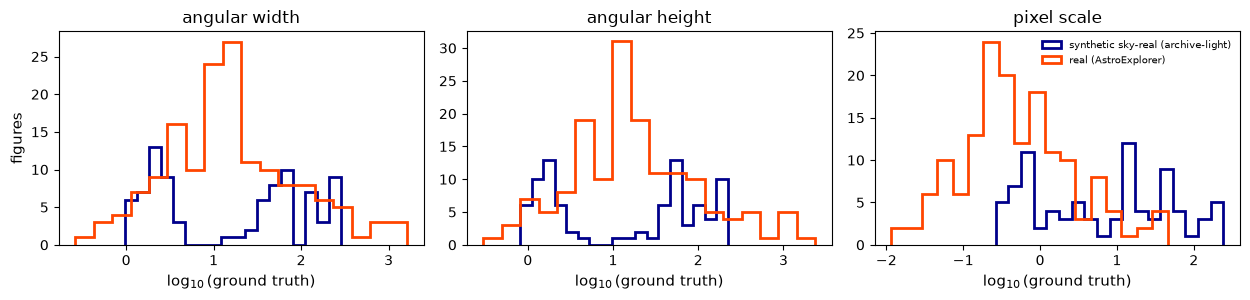

In [5]:
# ground-truth distribution per distribution -- the thing being asked ABOUT
gt = (df[np.isfinite(df['GT'])]
      .groupby(['question', 'source'])['GT']
      .describe()[['count', 'min', '25%', '50%', '75%', 'max']])
print('ground-truth values by row (arcmin for the two angular questions, '
      'arcsec for pixel scale):')
print(gt.round(3).to_string())

fig, axes = plt.subplots(1, len(questions), figsize=(4.2 * len(questions), 3.1))
axes = np.atleast_1d(axes)
for ax, (qlabel, _, qaxis, _) in zip(axes, questions):
    for src_label, _, _, color in active_sources:
        v = df[(df['question'] == qlabel) & (df['source'] == src_label)]['GT']
        v = v[np.isfinite(v) & (v > 0)]
        if len(v):
            ax.hist(np.log10(v), bins=18, histtype='step', linewidth=2,
                    color=color, label=src_label)
    ax.set_title(qlabel, fontsize=12)
    ax.set_xlabel(r'$\log_{10}$(ground truth)', fontsize=11)
    ax.tick_params(labelsize=10)
axes[0].set_ylabel('figures', fontsize=11)
axes[-1].legend(fontsize=7, frameon=False)
fig.tight_layout()
plt.show()

## The figure

In [6]:
def _draw_direction_arrows(ax):
    """"under estimate" / "over estimate", in the clear space beyond the guides."""
    tr = ax.get_xaxis_transform()
    lo, hi = logratio_xlim
    if show_factor_guides and factor_guides:
        g_lo, g_hi = min(factor_guides), max(factor_guides)
    else:
        g_lo = g_hi = 0.0
    pad = arrow_xpad_frac * (hi - lo)
    y = arrow_y_frac + arrow_y_nudge          # arrow and label move together

    for start, end, label in ((g_lo - pad, lo + pad, 'under estimate'),
                              (g_hi + pad, hi - pad, 'over estimate')):
        if abs(end - start) < 0.15 * (hi - lo):
            continue
        ax.annotate('', xy=(end, y), xytext=(start, y),
                    xycoords=tr, textcoords=tr, zorder=6,
                    arrowprops=dict(arrowstyle='-|>', color=arrow_color,
                                    lw=1.5, shrinkA=0, shrinkB=0))
        ax.text((start + end) / 2.0, y + arrow_label_gap, label, transform=tr,
                ha='center', va='bottom', fontsize=arrow_fontsize,
                color=arrow_color)


def plot_question_logratio(qlabel, ylim_in=None, show_legend=True):
    """
    Both distributions on ONE panel, overlaid.

    Plotted as densities, not counts: the samples are different sizes (85
    synthetic sky-real vs 156 real figures), so raw counts would make the real
    curve look taller for a reason that has nothing to do with accuracy.

    Each distribution gets a filled step histogram and a solid vertical line at
    its median -- the single number the summary table quotes, drawn where it
    can actually be compared against the other curve.
    """
    entry = next(q for q in questions if q[0] == qlabel)
    _, _, qaxis, out_file = entry
    bins = np.linspace(logratio_xlim[0], logratio_xlim[1], logratio_nbins)

    fig, ax = plt.subplots(figsize=(fig_width_in, fig_height_in))

    top = 0.0
    for src_label, _, _, color in active_sources:
        v = df[(df['question'] == qlabel) & (df['source'] == src_label)]['logratio'].values
        v = v[np.isfinite(v)]
        if len(v) == 0:
            continue
        med = float(np.median(v))
        lab = '%s  [n=%d' % (src_label, len(v))
        lab += ', %+.2f dex]' % med if show_medians_in_legend else ']'

        ax.hist(v, bins=bins, density=True, histtype='stepfilled',
                color=color, alpha=fill_alpha, zorder=2)
        ax.hist(v, bins=bins, density=True, histtype='step',
                color=color, linewidth=hist_thick, label=lab, zorder=3)
        if median_line:
            ax.axvline(med, color=color, linewidth=2.0, alpha=0.9, zorder=4)
        h, _ = np.histogram(v, bins=bins, density=True)
        top = max(top, h.max())

    if show_factor_guides:
        for g in factor_guides:
            ax.axvline(g, color='0.8', linestyle=':', linewidth=1.5, zorder=0)
    if show_zero_line:
        ax.axvline(0.0, color='gray', linestyle='--', linewidth=2, zorder=1)

    ax.set_xlim(logratio_xlim)
    if ylim_in is not None:
        ax.set_ylim(ylim_in)
    elif top > 0:
        ax.set_ylim(0.0, top * y_headroom *
                    (arrow_headroom if show_direction_arrows else 1.0))
    if show_direction_arrows:
        _draw_direction_arrows(ax)

    ax.set_xlabel(r'$\log_{10}(\mathrm{LMM}/\mathrm{GT})$  [dex]',
                  fontsize=axlabel_fontsize)
    ax.set_ylabel('density', fontsize=axlabel_fontsize)
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    ax.set_title('%s   %s' % (qlabel, qaxis), fontsize=fontsize)
    if show_legend:
        ax.legend(loc=legend_loc, fontsize=legend_fontsize, frameon=True,
                  framealpha=legend_framealpha, edgecolor='0.6')

    out_path = os.path.join(fig_out_dir, out_file)
    fig.savefig(out_path, bbox_inches='tight')
    print('wrote', out_path)

    recs = []
    for src_label, _, _, _c in active_sources:
        s = df[(df['question'] == qlabel) & (df['source'] == src_label)]
        if not len(s):
            continue
        lr = s['logratio'].values
        good = np.isfinite(lr)
        recs.append({
            'source': src_label, 'answers': len(s),
            'unparsable': int(s['LMM'].isna().sum()), 'plotted': int(good.sum()),
            'median dex': np.median(lr[good]) if good.any() else np.nan,
            'median factor': 10 ** np.median(lr[good]) if good.any() else np.nan,
            'within 2x %': 100 * np.mean(np.abs(lr[good]) < np.log10(2)) if good.any() else np.nan,
            'within 10x %': 100 * np.mean(np.abs(lr[good]) < 1.0) if good.any() else np.nan,
            'over %': 100 * np.mean(lr[good] > 0) if good.any() else np.nan,
            '>+1 dex %': 100 * np.mean(lr[good] > 1.0) if good.any() else np.nan,
            '<-1 dex %': 100 * np.mean(lr[good] < -1.0) if good.any() else np.nan,
        })
    print()
    print(pd.DataFrame(recs).to_string(index=False,
                                       float_format=lambda v: '%.2f' % v))
    return fig

### Angular width

wrote /Users/jnaiman/Dropbox/WASP2026/paper_figures/realsky_angular_width_logratio.pdf

                            source  answers  unparsable  plotted  median dex  median factor  within 2x %  within 10x %  over %  >+1 dex %  <-1 dex %
synthetic sky-real (archive-light)       85           0       85       -0.05           0.90        50.59         97.65   42.35       0.00       2.35
              real (AstroExplorer)      156           1      155       -0.26           0.55        36.13         94.84   22.58       0.00       5.16


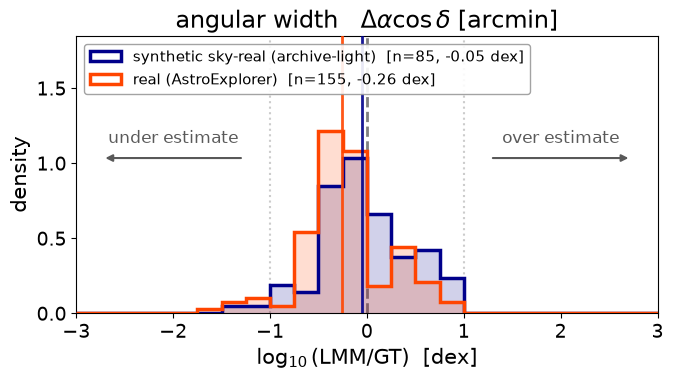

In [7]:
fig_w = plot_question_logratio('angular width')

### Angular height

wrote /Users/jnaiman/Dropbox/WASP2026/paper_figures/realsky_angular_height_logratio.pdf

                            source  answers  unparsable  plotted  median dex  median factor  within 2x %  within 10x %  over %  >+1 dex %  <-1 dex %
synthetic sky-real (archive-light)       85           0       85       -0.05           0.90        94.12         97.65   30.59       2.35       0.00
              real (AstroExplorer)      156           0      156       -0.23           0.59        67.95         90.38   17.31       7.69       1.92


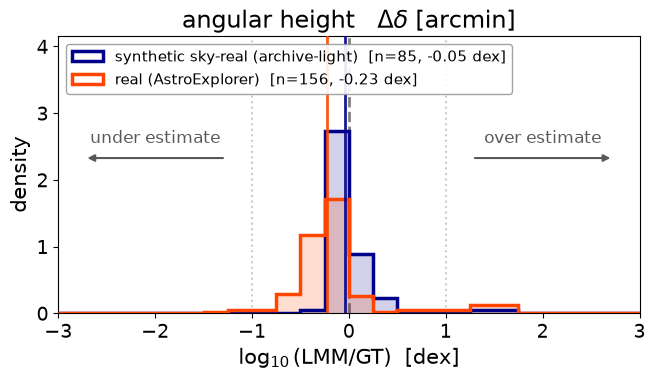

In [8]:
fig_h = plot_question_logratio('angular height')

### Pixel scale

wrote /Users/jnaiman/Dropbox/WASP2026/paper_figures/realsky_pixel_scale_logratio.pdf

                            source  answers  unparsable  plotted  median dex  median factor  within 2x %  within 10x %  over %  >+1 dex %  <-1 dex %
synthetic sky-real (archive-light)       85           1       84       -0.17           0.67        45.24         94.05   32.14       0.00       5.95
              real (AstroExplorer)      156           0      156        0.37           2.34        36.54         88.46   86.54      11.54       0.00


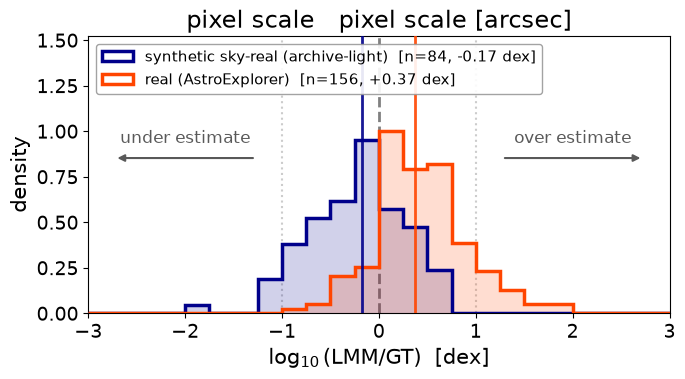

In [9]:
fig_p = plot_question_logratio('pixel scale')

## All three side by side

The numbers that go in the text. `median factor` is the median log-ratio
exponentiated -- 2.0 means "typically twice the true value", which is easier to
quote than 0.30 dex.


In [10]:
summary = []
for qlabel, _, _, _ in questions:
    for src_label, _, _, _c in active_sources:
        s = df[(df['question'] == qlabel) & (df['source'] == src_label)]
        lr = s['logratio'].values
        good = np.isfinite(lr)
        if not good.any():
            continue
        summary.append({
            'question': qlabel, 'source': src_label,
            'n': int(good.sum()), 'unparsable': int(s['LMM'].isna().sum()),
            'median dex': round(float(np.median(lr[good])), 3),
            'median factor': round(float(10 ** np.median(lr[good])), 2),
            'within 2x %': round(100 * float(np.mean(np.abs(lr[good]) < np.log10(2))), 1),
            'within 10x %': round(100 * float(np.mean(np.abs(lr[good]) < 1.0)), 1),
            'over %': round(100 * float(np.mean(lr[good] > 0)), 1),
        })
summary = pd.DataFrame(summary)
display(summary.set_index(['question', 'source']))

SYN  = active_sources[0][0]
REAL = 'real (AstroExplorer)'
print()
print('real vs %s, same question, same model:' % SYN)
for qlabel, _, _, _ in questions:
    a = summary[(summary['question'] == qlabel) & (summary['source'] == SYN)]
    b = summary[(summary['question'] == qlabel) & (summary['source'] == REAL)]
    if len(a) and len(b):
        a, b = a.iloc[0], b.iloc[0]
        print('   %-15s within 2x: %5.1f%% -> %5.1f%%   (%+.1f pts)   '
              'median %+.2f -> %+.2f dex'
              % (qlabel, a['within 2x %'], b['within 2x %'],
                 b['within 2x %'] - a['within 2x %'],
                 a['median dex'], b['median dex']))

summary.to_csv(os.path.join(fig_out_dir, 'realsky_vs_synthetic_logratio.csv'),
               index=False)
print()
print('wrote', os.path.join(fig_out_dir, 'realsky_vs_synthetic_logratio.csv'))

n  unparsable  \
question       source                                                
angular width  synthetic sky-real (archive-light)   85           0   
               real (AstroExplorer)                155           1   
angular height synthetic sky-real (archive-light)   85           0   
               real (AstroExplorer)                156           0   
pixel scale    synthetic sky-real (archive-light)   84           1   
               real (AstroExplorer)                156           0   

                                                   median dex  median factor  \
question       source                                                          
angular width  synthetic sky-real (archive-light)      -0.047           0.90   
               real (AstroExplorer)                    -0.257           0.55   
angular height synthetic sky-real (archive-light)      -0.045           0.90   
               real (AstroExplorer)                    -0.231           0.59   
pixel scale    synthetic sky-real (archive-light)      -0.173           0.67   
               real (AstroExplorer)                     0.369           2.34   

                                                   within 2x %  within 10x %  \
question       source                                                          
angular width  synthetic sky-real (archive-light)         50.6          97.6   
               real (AstroExplorer)                       36.1          94.8   
angular height synthetic sky-real (archive-light)         94.1          97.6   
               real (AstroExplorer)                       67.9          90.4   
pixel scale    synthetic sky-real (archive-light)         45.2          94.0   
               real (AstroExplorer)                       36.5          88.5   

                                                   over %  
question       source                                      
angular width  synthetic sky-real (archive-light)    42.4  
               real (AstroExplorer)                  22.6  
angular height synthetic sky-real (archive-light)    30.6  
               real (AstroExplorer)                  17.3  
pixel scale    synthetic sky-real (archive-light)    32.1  
               real (AstroExplorer)                  86.5


real vs synthetic sky-real (archive-light), same question, same model:
   angular width   within 2x:  50.6% ->  36.1%   (-14.5 pts)   median -0.05 -> -0.26 dex
   angular height  within 2x:  94.1% ->  67.9%   (-26.2 pts)   median -0.04 -> -0.23 dex
   pixel scale     within 2x:  45.2% ->  36.5%   (-8.7 pts)   median -0.17 -> +0.37 dex

wrote /Users/jnaiman/Dropbox/WASP2026/paper_figures/realsky_vs_synthetic_logratio.csv
